# IDEA
### 1. Feature-Specific Patterns

```python
# Learned c might look like:
c = [[0.9, 0.1, 0.1],   # Price: mostly cares about Price itself
     [0.3, 0.7, 0.0],   # Volume: mostly Volume, some Price
     [0.2, 0.1, 0.9]]   # RSI: mostly RSI itself
```
Interpretation:
- Price attention ignores Volume and RSI
- Volume attention moderately considers Price
- RSI attention ignores Volume



### 2. Cross-Feature Attention
```python
c = [[0.1, 0.8, 0.1],   # Price: mostly looks at Volume!
     [0.9, 0.1, 0.0],   # Volume: mostly looks at Price!
     [0.4, 0.4, 0.2]]   # RSI: balanced look
```
Interpretation:
- Price attention triggered by high Volume (trading activity)
- Volume attention triggered by Price movements
- RSI considers both

### 3. Task-Specific Attention
```python
# For anomaly detection task:
c = [[0.9, 0.0, 0.1],   # Price: extreme prices matter
     [0.0, 1.0, 0.0],   # Volume: only volume extremes matter
     [0.1, 0.0, 0.9]]   # RSI: only extreme RSI matters

# For trend prediction task:
c = [[0.3, 0.4, 0.3],   # Price: all features matter
     [0.3, 0.4, 0.3],   # Volume: all features matter
     [0.3, 0.4, 0.3]]   # RSI: all features matter

# c matrix: 3 features × 3 features
# Each COLUMN is attention vector for a feature

# Let's say model learns:
c = [[0.8, 0.1, 0.0],   # Column 0: Price attention
     [0.1, 0.9, 0.2],   # Column 1: Volume attention
     [0.1, 0.0, 0.8]]   # Column 2: RSI attention

# Interpretation:
# - Price attention: 80% Price, 10% Volume, 10% RSI
# - Volume attention: 10% Price, 90% Volume, 0% RSI  
# - RSI attention: 0% Price, 20% Volume, 80% RSI
```
### 4. Mathematical Proof

**Original:**

Let $\mathbf{c} = [c_1, c_2, c_3]$  
For any time step with features $\mathbf{f} = [f_1, f_2, f_3]$:  
$\text{score} = f_1 \cdot c_1 + f_2 \cdot c_2 + f_3 \cdot c_3$  
This score is used for **ALL** features.

**New:**

Let $\mathbf{} = \begin{bmatrix}
c_{11} & c_{12} & c_{13} \\  % For feature 1
c_{21} & c_{22} & c_{23} \\  % For feature 2
c_{31} & c_{32} & c_{33}     % For feature 3
\end{bmatrix}$

For feature 1 attention: $\text{score}_1 = f_1 \cdot c_{11} + f_2 \cdot c_{21} + f_3 \cdot c_{31}$  
For feature 2 attention: $\text{score}_2 = f_1 \cdot c_{12} + f_2 \cdot c_{22} + f_3 \cdot c_{32}$  
For feature 3 attention: $\text{score}_3 = f_1 \cdot c_{13} + f_2 \cdot c_{23} + f_3 \cdot c_{33}$

**DIFFERENT formulas for each feature!**


# PREPROCESSING


## Import

In [4]:
import os
os.environ['TF_FORCE_GPU_ALLOW_GROWTH'] = 'true'  # Add at VERY TOP of script
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # Reduce TensorFlow logging
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import gc
import ssl
import zipfile
import urllib3
import os
import requests
from pathlib import Path
from tqdm import tqdm 
import json
import math
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib.ticker import MaxNLocator
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import warnings
from datetime import datetime
warnings.filterwarnings('ignore')
import time
import tensorflow as tf
from tensorflow.keras.layers import (
    Layer, Input, LSTM, Dense, Dropout, Bidirectional, 
    LayerNormalization, Concatenate, Reshape, Lambda
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import AdamW
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.layers import MultiHeadAttention
from tensorflow.keras.layers import Softmax
import pandas as pd
from tensorflow.keras import layers, Model
from tensorflow.keras.models import load_model
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.layers import RepeatVector
from tensorflow.keras.models import Model,Sequential
from tensorflow.keras.layers import Lambda, Input,Conv1D, LSTM, Dense, Dropout,Bidirectional, Layer,LayerNormalization
from tensorflow.keras.optimizers import Adam
import random
import keras
from tensorflow.keras.layers import (
    Input, LSTM, Dense, Dropout, Add, LayerNormalization
)
from tensorflow.keras.layers import Reshape
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_squared_error, mean_absolute_error
import tensorflow as tf
from tensorflow.keras.layers import Attention
from tensorflow.keras.layers import Concatenate
from tensorflow.keras.callbacks import ModelCheckpoint

## Data Preprocessing

In [5]:
# ===============================
# Global Experiment Settings 
# ===============================
dataset_name = 'ETTh2'
single_or_muti_target = 'S' # S for single feature(same as target),M for all features
input_len = 336
RUNS = 3
batch_size = 32 
epochs = 30
num_features = 7 if single_or_muti_target=="M" else 1
################################################################
################################################################
# Disable SSL warnings (optional)
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)
# Create unverified SSL context
ssl._create_default_https_context = ssl._create_unverified_context


# 1. Create the dataset directory
dataset_dir = Path('./data/raw')
dataset_dir.mkdir(exist_ok=True)

# Path to check if the zip file already exists
zip_path = dataset_dir / 'all_six_datasets.zip'

# Check if the zip file already exists
if zip_path.exists():
    print(f"✅ Zip file already exists at {zip_path}, skipping download...")
else:
    # 2. Download the official benchmark zip file
    url = "https://www.dropbox.com/s/rlc1qmprpvuqrsv/all_six_datasets.zip?dl=1"
    print("Downloading benchmark datasets (approx. 70MB)...")
        
    # Download with SSL verification disabled
    response = requests.get(url, stream=True, verify=False)
    file_size = int(response.headers.get('content-length', 0))
        
    with open(zip_path, 'wb') as f:
        with tqdm(total=file_size, unit='B', unit_scale=True, desc="Downloading") as pbar:
            for chunk in response.iter_content(chunk_size=8192):
                f.write(chunk)
                pbar.update(len(chunk))

# Check if datasets are already extracted (by checking if Exchange folder exists)
exchange_path = dataset_dir / dataset_name / 'Y_df.csv'
if exchange_path.exists():
    print(f"✅ Dataset {dataset_name} already exists at {exchange_path}, skipping extraction...")
else:
    # 3. Extract the zip file
    print("Extracting files...")
    dataset_dir.mkdir(exist_ok=True)
        
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        files = zip_ref.namelist()
        with tqdm(total=len(files), desc="Extracting") as pbar:
            for file in files:
                zip_ref.extract(file, dataset_dir)
                pbar.update(1)
    
    # 4. Move files from all_six_datasets to dataset_dir
    extracted_subdir = dataset_dir / 'all_six_datasets'
    if extracted_subdir.exists():
        print("Moving dataset folders to main directory...")
        for item in extracted_subdir.iterdir():
            dest_path = dataset_dir / item.name
            
            # Handle existing files/folders at destination
            if dest_path.exists():
                if dest_path.is_dir():
                    print(f"  - Removing existing directory {dest_path}")
                    shutil.rmtree(dest_path)
                else:
                    print(f"  - Removing existing file {dest_path}")
                    dest_path.unlink()
            
            print(f"  - Moving {item.name} to {dataset_dir}")
            shutil.move(str(item), str(dataset_dir))
        
        # Remove the now-empty all_six_datasets directory
        if extracted_subdir.exists():
            print("Removing empty all_six_datasets directory...")
            shutil.rmtree(extracted_subdir)
    
    # 5. Remove __MACOSX folder if it exists
    macosx_path = dataset_dir / '__MACOSX'
    if macosx_path.exists():
        print("Removing __MACOSX folder...")
        if macosx_path.is_dir():
            shutil.rmtree(macosx_path)
        else:
            macosx_path.unlink()
    
    # Also remove any .DS_Store files that might exist
    print("Cleaning up .DS_Store files...")
    for ds_store in dataset_dir.glob('**/.DS_Store'):
        print(f"  - Removing {ds_store}")
        ds_store.unlink()
    
    # 6. Clean up the zip file (optional - comment out if you want to keep it)
    # zip_path.unlink()
    # print(f"✅ Extraction complete, zip file removed")

print("\n✅ Success! Your dataset folder structure:")
for item in sorted(dataset_dir.iterdir()):
    if item.is_dir():
        print(f"  📁 {item.name}/")
        # Show first few files in each dataset directory
        try:
            all_files = list(item.iterdir())
            # Filter out hidden files like .DS_Store
            visible_files = [f for f in all_files if not f.name.startswith('.')]
            for f in visible_files[:3]:
                if f.is_dir():
                    print(f"      📁 {f.name}/")
                else:
                    print(f"      📄 {f.name}")
            if len(visible_files) > 3:
                print(f"      ... and {len(visible_files) - 3} more")
        except:
            pass
    else:
        if item.suffix == '.zip':
            print(f"  📦 {item.name}")
        elif not item.name.startswith('.'):  # Skip hidden files
            print(f"  📄 {item.name}")

# Load and display the dataset
file_path = dataset_dir / dataset_name / 'Y_df.csv'
if file_path.exists():
    df = pd.read_csv(file_path)
    df['date'] = pd.to_datetime(df['date'])
    print(f"\n📊 {dataset_name} dataset preview:")
    print(df.head())
    print(f"\n📊 Dataset shape: {df.shape}")
    
    # Show unique IDs if they exist
    if 'unique_id' in df.columns:
        print(f"\n📊 Unique IDs: {df['unique_id'].nunique()}")
else:
    print(f"\n❌ Error: Could not find {file_path}")
    print("Available datasets:")
    for item in dataset_dir.iterdir():
        if item.is_dir() and not item.name.startswith('.'):
            print(f"  - {item.name}")

✅ Zip file already exists at data/raw/all_six_datasets.zip, skipping download...
✅ Dataset ETTh2 already exists at data/raw/ETTh2/Y_df.csv, skipping extraction...

✅ Success! Your dataset folder structure:
  📁 ECL/
      📄 Y_df.csv
  📁 ETTh1/
      📄 Y_df.csv
  📁 ETTh2/
      📄 Y_df.csv
  📁 ETTm1/
      📄 Y_df.csv
  📁 ETTm2/
      📄 Y_df.csv
  📁 Exchange/
      📄 Y_df.csv
  📁 ILI/
      📄 Y_df.csv
  📁 TrafficL/
      📄 Y_df.csv
  📁 Weather/
      📄 Y_df.csv
  📦 all_six_datasets.zip

📊 ETTh2 dataset preview:
                 date       HUFL    HULL       MUFL   MULL   LUFL   LULL  \
0 2016-07-01 00:00:00  41.130001  12.481  36.535999  9.355  4.424  1.311   
1 2016-07-01 01:00:00  37.528000  10.136  33.936001  7.532  4.435  1.215   
2 2016-07-01 02:00:00  37.946999  11.309  35.330002  9.007  2.100  0.000   
3 2016-07-01 03:00:00  38.952000  11.895  35.543999  9.436  3.380  1.215   
4 2016-07-01 04:00:00  38.113998  11.476  35.410000  9.623  2.036  0.000   

          OT  
0  38.661999  


In [6]:
repo_url = "https://github.com/yuqinie98/PatchTST.git"
repo_name = "PatchTST"

if not os.path.exists(repo_name):
    subprocess.run(["git", "clone", repo_url])
    print(f"Cloned {repo_url}")
else:
    print(f"Directory '{repo_name}' already exists. Skipping clone.")
# Import their exact data loader
import sys
sys.path.append('PatchTST/PatchTST_supervised')
from data_provider.data_loader import Dataset_ETT_hour
print("✓ Successfully imported PatchTST data loader")

# Clone PatchTST repository
import os
import subprocess

repo_url = "https://github.com/yuqinie98/PatchTST.git"
repo_name = "PatchTST"

if not os.path.exists(repo_name):
    subprocess.run(["git", "clone", repo_url])
    print(f"Cloned {repo_url}")
else:
    print(f"Directory '{repo_name}' already exists. Skipping clone.")
# Import their exact data loader
import sys
sys.path.append('PatchTST/PatchTST_supervised')
from data_provider.data_loader import Dataset_ETT_hour
print("✓ Successfully imported PatchTST data loader")

# Import the correct loaders
from data_provider.data_loader import Dataset_ETT_hour, Dataset_Custom
if 'ETT' in dataset_name:
    DatasetClass = Dataset_ETT_hour
else:
    DatasetClass = Dataset_Custom 
    
def input_pred_len(seq_len=336, pred_len=96, dataset='Y_df'):
    """
    Universal data loader for PatchTST univariate forecasting.
    Supports: ETTh1, ETTh2, ETTm1, ETTm2, Exchange, Weather, Electricity, Traffic, ILI
    """

    target_col = 'OT'
    # Create datasets with features='S' (univariate input, univariate output)
    path_file = dataset_dir / dataset_name 
    train_dataset = DatasetClass(
        
        root_path=path_file ,
        flag='train',
        size=[seq_len, 0, pred_len],
        features=single_or_muti_target,           # Univariate mode
        data_path=f'{dataset}.csv',
        target=target_col,      # The column to predict
        scale=True,
        timeenc=0,             # No time features
        freq='h'               # Frequency placeholder; not used when timeenc=0
    )

    val_dataset = DatasetClass(
        root_path=path_file,
        flag='val',
        size=[seq_len, 0, pred_len],
        features=single_or_muti_target,
        data_path=f'{dataset}.csv',
        target=target_col,
        scale=True,
        timeenc=0,
        freq='h'
    )

    test_dataset = DatasetClass(
        root_path=path_file,
        flag='test',
        size=[seq_len, 0, pred_len],
        features=single_or_muti_target,
        data_path=f'{dataset}.csv',
        target=target_col,
        scale=True,
        timeenc=0,
        freq='h'
    )

    # Extract numpy arrays (works identically for both loader classes)
    def extract_data(ds):
        X, y = [], []
        for i in range(len(ds)):
            seq_x, seq_y, _, _ = ds[i]
            # seq_x: (seq_len, n_features)   ← ALL features (e.g., 8 for Exchange)
            # seq_y: (pred_len, 1)           ← only the target column
            X.append(seq_x)
            y.append(seq_y[-pred_len:, 0])  # (pred_len,)
        return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

    x_train, y_train = extract_data(train_dataset)
    x_val,   y_val   = extract_data(val_dataset)
    x_test,  y_test  = extract_data(test_dataset)

    # Get the scaler (fitted on ALL features because features='M')
    scaler = train_dataset.scaler
    n_total_features = scaler.n_features_in_   # e.g., 8 for Exchange, 7 for ETT

    # ---- CORRECT INVERSE TRANSFORM ----
    # y_test shape: (N, pred_len)
    y_test_flat = y_test.reshape(-1)                     # (N * pred_len,)
    dummy = np.zeros((len(y_test_flat), n_total_features))
    # Assume target column is the LAST column (true for all PatchTST preprocessed files)
    dummy[:, -1] = y_test_flat
    y_test_orig_flat = scaler.inverse_transform(dummy)[:, -1]
    y_test_orig = y_test_orig_flat.reshape(y_test.shape)
    # -----------------------------------

    return x_train, y_train, x_val, y_val, x_test, y_test, scaler, scaler, y_test_orig

Directory 'PatchTST' already exists. Skipping clone.
✓ Successfully imported PatchTST data loader
Directory 'PatchTST' already exists. Skipping clone.
✓ Successfully imported PatchTST data loader


# RubickAttention

## Structure

In [7]:
# ===================================================
#  Rubick_Attention_Block (fast_parralell) 
#  with learnable head weights before concatenation
# ===================================================
class Rubick_Attention_Block(layers.Layer):
    def __init__(self, n_heads=1, multi_layer=False, use_residual=True,
                 use_scaling=True, soft_max_axis=-1, **kwargs):
        super(Rubick_Attention_Block, self).__init__(**kwargs)
        self.n_heads = n_heads
        self.multi_layer = multi_layer
        self.use_residual = use_residual
        self.use_scaling = use_scaling
        self.soft_max_axis = soft_max_axis

    def build(self, input_shape):
        self.features = input_shape[-1]

        # W and b weights
        self.W = self.add_weight(
            shape=(self.features, self.features),
            initializer="glorot_uniform",
            trainable=True,
            name="att_weight"
        )
        self.b = self.add_weight(
            shape=(self.features,),
            initializer="zeros",
            trainable=True,
            name="att_bias"
        )

        # Context vectors
        self.c = self.add_weight(
            shape=(self.n_heads, self.features, self.features),
            initializer="glorot_uniform",
            trainable=True,
            name="context_vector"
        )

        # Learnable head weights (for multi‑layer mode with >1 heads)
        if self.multi_layer and self.n_heads > 1:
            self.head_weights = self.add_weight(
                shape=(self.n_heads,),
                initializer="ones",
                trainable=True,
                name="head_weights"
            )

        # Output projection for multi-head (normal mode only)
        if not self.multi_layer and self.n_heads > 1:
            self.output_projection = self.add_weight(
                shape=(self.n_heads * self.features, self.features),
                initializer="glorot_uniform",
                trainable=True,
                name="output_projection"
            )
            self.output_bias = self.add_weight(
                shape=(self.features,),
                initializer="zeros",
                trainable=True,
                name="output_bias"
            )

        # Layer normalization for residual
        if self.use_residual and not self.multi_layer:
            self.layer_norm = layers.LayerNormalization(epsilon=1e-6)

        super(Rubick_Attention_Block, self).build(input_shape)

    def call(self, x):
        

        
        batch_size = tf.shape(x)[0]
        seq_len = tf.shape(x)[1]

        #------------- a learned, non‑linear Transformation --------------------
        #linear transformation followed by a hyperbolic tangent activation,
        #which is a common building block in neural networks (e.g., in LSTM cells, GRU, or fully connected layers)
        #Because tf.tanh is applied, every element of c_it will be in the range (-1, 1) 
        #(theoretically exclusive, but in practice very close to -1 or 1 for large inputs).
        #The hyperbolic tangent function squashes any real number to this interval
        c_it = tf.tanh(tf.tensordot(x, self.W, axes=1) + self.b)
        # --------------------- scale -----------------------------------------
        #This is a common trick in attention mechanisms (like in Transformers) 
        #to prevent the dot products from becoming too large and pushing the softmax into
        #regions with extremely small gradients.
        scale = tf.sqrt(tf.cast(self.features, tf.float32)) if self.use_scaling else 1.0
        # ---------------------- multi_layer or one_layer ----------------------------------
        #The code then checks if self.multi_layer. If True, it enters a “parallel” version 
        #designed to handle multiple heads.
        if self.multi_layer:
            # --------------------- attention_core ---------------------------
            ###################### 1.Feature‑specific patterns
            # c = [[0.9, 0.1, 0.1],   # Price: mostly cares about Price itself
            #     [0.3, 0.7, 0.0],    # Volume: mostly Volume, some Price
            #     [0.2, 0.1, 0.9]]    # RSI: mostly RSI itself
            #
            # Column 0 = [0.9, 0.3, 0.2] – this is the attention vector for output feature 0 (say, Price). It says: to compute the score for Price, take 90% of the input Price, 30% of Volume, and 20% of RSI.
            # Column 1 = [0.1, 0.7, 0.1] – for output feature 1 (Volume), use 10% Price, 70% Volume, 10% RSI.
            # Column 2 = [0.1, 0.0, 0.9] – for output feature 2 (RSI), use 10% Price, 0% Volume, 90% RSI.
            #That’s exactly what einsum('btd,df->btf') implements: each output feature f
            #gets its score from a dot product between the input features and column f of c.
            ###################### 2. Cross-Feature Attention
            # c = [[0.1, 0.8, 0.1],   # Price: mostly looks at Volume!
            #      [0.9, 0.1, 0.0],   # Volume: mostly looks at Price!
            #      [0.4, 0.4, 0.2]]   # RSI: balanced look
            # Interpretation:
            # Price attention triggered by high Volume (trading activity)
            # Volume attention triggered by Price movements
            # RSI considers both
            ###################### 3. Task-Specific Attention
            # # For anomaly detection task:
            # c = [[0.9, 0.0, 0.1],   # Price: extreme prices matter
            #      [0.0, 1.0, 0.0],   # Volume: only volume extremes matter
            #      [0.1, 0.0, 0.9]]   # RSI: only extreme RSI matters
            # # For trend prediction task:
            # c = [[0.3, 0.4, 0.3],   # Price: all features matter
            #      [0.3, 0.4, 0.3],   # Volume: all features matter
            #      [0.3, 0.4, 0.3]]   # RSI: all features matter
            # # c matrix: 3 features × 3 features
            # # Each COLUMN is attention vector for a feature
            # # Let's say model learns:
            # c = [[0.8, 0.1, 0.0],   # Column 0: Price attention
            #      [0.1, 0.9, 0.2],   # Column 1: Volume attention
            #      [0.1, 0.0, 0.8]]   # Column 2: RSI attention
            ####################### Interpretation:
            # # - Price attention: 80% Price, 10% Volume, 10% RSI
            # # - Volume attention: 10% Price, 90% Volume, 0% RSI  
            # # - RSI attention: 0% Price, 20% Volume, 80% RSI
                
            if self.n_heads == 1:
                a_it = tf.einsum('btd,df->btf', c_it, self.c[0]) / scale
                a_it_softmax = tf.nn.softmax(a_it, axis=-1)
                output = x * a_it_softmax
                return output

            # Compute attention for all heads simultaneously
            a_it_all = tf.einsum('btd,hdf->bhtf', c_it, self.c) / scale      # (batch, n_heads, seq_len, features)
            a_it_softmax_all = tf.nn.softmax(a_it_all, axis=-1)               # softmax over time

            # Expand x to match dimensions
            x_expanded = tf.expand_dims(x, axis=1)                           # (batch, 1, seq_len, features)
            weighted_all = x_expanded * a_it_softmax_all                     # (batch, n_heads, seq_len, features)
            # ------------ Multiply each head by its learnable weight - one scalar per attention head. ----
            #Each head’s entire contribution (every feature at every position) 
            #is multiplied by a learned scalar. 
            #This can be interpreted as a soft form of head selection
            #the model can learn to up‑ or down‑weight entire heads
            #possibly to focus on more important heads or to suppress irrelevant ones.
            if hasattr(self, 'head_weights'):
                # Reshape head_weights to (1, n_heads, 1, 1) for broadcasting
                head_weights_reshaped = tf.reshape(self.head_weights, (1, self.n_heads, 1, 1))
                weighted_all = weighted_all * head_weights_reshaped
            # ------------ rearranges dimensions  -------------------------
            #then concatenates the heads into a single vector per sequence position
            #Reshape to concatenate heads along feature dimension
            # if each head output is a matrix of shape (2, 3) 
            #(batch/sequence flattened for simplicity), concatenating them horizontally gives a (2, 6) matrix 
            weighted_reshaped = tf.reshape(
                tf.transpose(weighted_all, [0, 2, 1, 3]), # (batch, seq_len, n_heads, features)
                [batch_size, seq_len, self.n_heads * self.features] # (batch_size, seq_len, n_heads * features)
            )
            # -------- rubick triger ---------------
            #applies the softmax function to the tensor weighted_reshaped
            #along the dimension specified by self.soft_max_axis
            #If self.soft_max_axis = -1 (the last dimension)
            #Softmax is applied over the concatenated head‑feature dimension.
            #For each token in the sequence, the vector of length n_heads * features is converted into a probability distribution that sums to 1.
            #This means the output for a given token represents how the total “mass” is distributed among all the individual elements coming from all heads.
            #Interpretation: This could be seen as a kind of “feature‑wise attention” 
            #or a mixture model where each element of the concatenated vector competes 
            #for probability. It’s less common in standard Transformers but might be used in specialised layers (e.g., for multi‑label classification or to produce a sparse representation).
            #If self.soft_max_axis = 1 (the sequence length dimension)
            #Softmax is applied over the concatenated head‑feature dimension.
            #For each token in the sequence, the vector of length n_heads * features is converted into a probability distribution that sums to 1.
            #This means the output for a given token represents how the total “mass” is distributed among all the individual elements coming from all heads.
            #Interpretation: This could be seen as a kind of “feature‑wise attention” or a mixture model where each element of the concatenated vector competes for probability. 
            #It’s less common in standard Transformers but might be used in specialised layers (e.g., for multi‑label classification or to produce a sparse representation).
            output = tf.nn.softmax(weighted_reshaped, axis=self.soft_max_axis)
            return output
            
        # non-multi-layer
        if self.n_heads == 1:
            a_it = tf.einsum('btd,df->btf', c_it, self.c[0]) / scale
            a_it_softmax = tf.nn.softmax(a_it, axis=-1)
            output = x * a_it_softmax
        else:
            # Multi-head attention in non-multi-layer mode
            a_it_all = tf.einsum('btd,hdf->bhtf', c_it, self.c) / scale
            a_it_softmax_all = tf.nn.softmax(a_it_all, axis=-1)
            x_expanded = tf.expand_dims(x, axis=1)
            weighted_all = x_expanded * a_it_softmax_all
            # ------------ Multiply each head by its learnable weight - one scalar per attention head. ----
            #Each head’s entire contribution (every feature at every position) 
            #is multiplied by a learned scalar. 
            #This can be interpreted as a soft form of head selection
            #the model can learn to up‑ or down‑weight entire heads
            #possibly to focus on more important heads or to suppress irrelevant ones.
            if hasattr(self, 'head_weights'):
                # Reshape head_weights to (1, n_heads, 1, 1) for broadcasting
                head_weights_reshaped = tf.reshape(self.head_weights, (1, self.n_heads, 1, 1))
                weighted_all = weighted_all * head_weights_reshaped
            # ----- for n_heads > 1 and for multi_layer is false --------
            #rearranges dimensions and 
            #then concatenates the heads into a single vector per sequence position
            #Reshape to concatenate heads along feature dimension
            # if each head output is a matrix of shape (2, 3) 
            #(batch/sequence flattened for simplicity), concatenating them horizontally gives a (
            concatenated = tf.reshape(
                tf.transpose(weighted_all, [0, 2, 1, 3]),# (batch, seq_len, n_heads, features)
                [batch_size, seq_len, self.n_heads * self.features]#(batch_size, seq_len, n_heads * features)
            )
            # ----- for n_heads > 1 and for multi_layer is false --------
            ##performs a linear projection that combines 
            ##the multi‑head outputs into a single representation
            ##In the context of Multi-Head Attention, 
            ##you have just concatenated multiple "heads" together. 
            ##This step merges that information back into the original feature dimension 
            output = tf.tensordot(concatenated, self.output_projection, axes=1) + self.output_bias
            output = tf.nn.relu(output)            
            # -------- rubick triger ---------------
            #applies the softmax function to the tensor weighted_reshaped
            #along the dimension specified by self.soft_max_axis
            #If self.soft_max_axis = -1 (the last dimension)
            #Softmax is applied over the concatenated head‑feature dimension.
            #For each token in the sequence, the vector of length n_heads * features is converted into a probability distribution that sums to 1.
            #This means the output for a given token represents how the total “mass” is distributed among all the individual elements coming from all heads.
            #Interpretation: This could be seen as a kind of “feature‑wise attention” 
            #or a mixture model where each element of the concatenated vector competes 
            #for probability. It’s less common in standard Transformers but might be used in specialised layers (e.g., for multi‑label classification or to produce a sparse representation).
            #If self.soft_max_axis = 1 (the sequence length dimension)
            #Softmax is applied over the concatenated head‑feature dimension.
            #For each token in the sequence, the vector of length n_heads * features is converted into a probability distribution that sums to 1.
            #This means the output for a given token represents how the total “mass” is distributed among all the individual elements coming from all heads.
            #Interpretation: This could be seen as a kind of “feature‑wise attention” or a mixture model where each element of the concatenated vector competes for probability. 
            #It’s less common in standard Transformers but might be used in specialised layers (e.g., 
            output = tf.nn.softmax(output, axis=self.soft_max_axis)
            # -----------------------------------------------------------
        # Add residual connection
        if self.use_residual:
            output = output + x

        # Apply layer normalization
        if hasattr(self, 'layer_norm'):
            output = self.layer_norm(output)
        
        return output

    def compute_output_shape(self, input_shape):
        if self.multi_layer:
            if self.n_heads == 1:
                return input_shape
            else:
                return (input_shape[0], input_shape[1], self.n_heads * input_shape[2])
        else:
            return input_shape

    def get_config(self):
        config = super(Rubick_Attention_Block, self).get_config()
        config.update({
            'n_heads': self.n_heads,
            'multi_layer': self.multi_layer,
            'use_residual': self.use_residual,
            'use_scaling': self.use_scaling,
            'soft_max_axis': self.soft_max_axis
        })
        return config

# ===================================================
#  PerChannelActivation
# ===================================================    
class PerChannelActivation(layers.Layer):
    """Learnable activation applied independently to each channel"""
    def __init__(self, activation_type='elu', **kwargs):
        super(PerChannelActivation, self).__init__(**kwargs)
        self.activation_type = activation_type
        
    def build(self, input_shape):
        # input_shape: (batch, num_channels, timesteps)
        self.num_channels = input_shape[1]
        
        if self.activation_type == 'pelu':  # Parametric ELU
            # Two parameters per channel: alpha (for negative) and beta (for positive)
            self.alpha = self.add_weight(
                name='alpha',
                shape=(self.num_channels,),
                initializer='ones',
                trainable=True
            )
            self.beta = self.add_weight(
                name='beta',
                shape=(self.num_channels,),
                initializer='ones',
                trainable=True
            )
        elif self.activation_type == 'prelu':  # Parametric ReLU
            self.alpha = self.add_weight(
                name='alpha',
                shape=(self.num_channels,),
                initializer=tf.keras.initializers.Constant(0.1),
                trainable=True
            )
        elif self.activation_type == 'pswish':  # Parametric Swish
            self.beta = self.add_weight(
                name='beta',
                shape=(self.num_channels,),
                initializer='ones',
                trainable=True
            )
        elif self.activation_type == 'mix':  # Mixture of activations
            # Learn weights for different activations per channel
            self.weights = self.add_weight(
                name='weights',
                shape=(self.num_channels, 3),  # weights for [ReLU, Sigmoid, Tanh]
                initializer='ones',
                trainable=True
            )
        
        super(PerChannelActivation, self).build(input_shape)
    
    def call(self, inputs):
        # Expand parameters for broadcasting
        if self.activation_type == 'pelu':
            alpha = tf.expand_dims(self.alpha, axis=0)   # (1, num_channels)
            alpha = tf.expand_dims(alpha, axis=-1)       # (1, num_channels, 1)
            beta = tf.expand_dims(self.beta, axis=0)
            beta = tf.expand_dims(beta, axis=-1)
            
            # PELU: f(x) = alpha * (exp(x) - 1) for x < 0, beta * x for x >= 0
            return tf.where(inputs >= 0, beta * inputs, alpha * (tf.exp(inputs) - 1))
            
        elif self.activation_type == 'prelu':
            alpha = tf.expand_dims(self.alpha, axis=0)
            alpha = tf.expand_dims(alpha, axis=-1)
            return tf.where(inputs >= 0, inputs, alpha * inputs)
            
        elif self.activation_type == 'pswish':
            beta = tf.expand_dims(self.beta, axis=0)
            beta = tf.expand_dims(beta, axis=-1)
            return inputs * tf.nn.sigmoid(beta * inputs)
            
        elif self.activation_type == 'mix':
            weights = tf.nn.softmax(self.weights, axis=-1)  # Normalize weights
            weights = tf.expand_dims(weights, axis=0)       # (1, num_channels, 3)
            weights = tf.expand_dims(weights, axis=-1)      # (1, num_channels, 3, 1)
            
            # Compute each activation
            relu_out = tf.nn.relu(inputs)
            sigmoid_out = tf.nn.sigmoid(inputs)
            tanh_out = tf.nn.tanh(inputs)
            
            # Stack activations: (batch, num_channels, timesteps, 3)
            activations = tf.stack([relu_out, sigmoid_out, tanh_out], axis=-1)
            
            # Weighted sum: sum(weight * activation) over last dimension
            weighted = tf.reduce_sum(weights * activations, axis=-1)
            
            return weighted
        
        else:
            return inputs  # Identity if unknown type
    
    def compute_output_shape(self, input_shape):
        return input_shape   
# ===================================================
#  Rubick Attention
# ===================================================
def Rubick_Attention_Model(
    input_len=336,
    pred_len=96,
    num_features=1,
    n_layer_rubickattention=1,
    use_rubickattention=True,
    n_heads_rubickattention=4,
    use_scaling_rubickattention=False,
    use_residual_rubickattention=False,
    dropout=0.1,
    dd_model=2048,
    conv_size=7

):
   
    print(f"[DEBUG] Building model with input shape: ({input_len}, {num_features})")    
    inputs = layers.Input(shape=(input_len, num_features))
    x = inputs
    
    print(f"[DEBUG] Input shape: {inputs.shape}")
    num_features = x.shape[-1]


    if n_layer_rubickattention <= 1:
        print(f"[DEBUG] Adding attention layer")
        x = Rubick_Attention_Block(
            n_heads=n_heads_rubickattention,
            multi_layer=False,
            use_residual=use_residual_rubickattention,
            use_scaling=use_scaling_rubickattention,
            soft_max_axis=-2)(x)
    else:
        for i in range(1, n_layer_rubickattention):
            print(f"[DEBUG] Adding multi-layer attention layer {i} with input features: {num_features}")
            # --------------------Alternating softmax axes----------------------------------------
            #In the multi‑layer version, we alternate between row‑wise (axis=-1, over features) and column‑wise (axis=-2, over sequence length) softmax.
            #Row‑wise softmax makes each feature’s attention scores compete across features for a given time step.
            #Column‑wise softmax makes each time step’s attention scores compete across time for a given feature.
            #By alternating, each element of the attention matrix must satisfy two normalization constraints,
            #creating a trade‑off that can lead to more balanced or specialized attention patterns. 
            #This is reminiscent of Sinkhorn normalization (iterative row/column normalization) used in some optimal transport and attention models.
            #Why alternate softmax?
            #In standard self‑attention, we usually have only one softmax (over keys). 
            #Here, applying softmax over both dimensions in successive layers forces 
            #the attention weights to be doubly stochastic in the limit (if repeated enough). 
            #This can encourage the model to distribute attention more uniformly or to learn more structured alignments.
            #Effect on learning:
            #The alternating normalization may help the model escape local minima where
            #one feature dominates attention across all time steps, because the column‑wise normalization would penalize such a pattern.
            #It also introduces a form of competition both among features and among time steps, potentially leading to more informative representations.
            #Connection to your hypothesis:
            #how weight vectors adjust based on input variations is consistent with gradient descent dynamics.
            #The alternating softmax adds an extra layer of constraints that shape the loss landscape and influence how those adjustments occur.
            f i%2 == 0:
                soft_max_axis = -1
            else: 
                soft_max_axis = -2
            # Add projection layer after multi-head concatenation to maintain dimension
            if n_heads_rubickattention > 1:
                # First apply multi-layer attention
                x_multi = Rubick_Attention_Block(
                    n_heads=n_heads_rubickattention, 
                    multi_layer=True,
                    use_residual=False,  # Don't use residual here since we'll project
                    use_scaling=use_scaling_rubickattention,
                    soft_max_axis=soft_max_axis)(x)
                    
                # Add projection to return to original dimension
                x_proj = layers.Dense(
                    num_features,
                    activation='relu',
                    name=f'proj_layer_{i}'
                )(x_multi)
                    
                # Now add residual connection
                x = layers.add([x, x_proj])
                    
            else:
                # For single head, just use normal mode
                x = Rubick_Attention_Block(
                    n_heads=n_heads_rubickattention,
                    multi_layer=True,
                    use_residual=use_residual_rubickattention,
                    use_scaling=use_scaling_rubickattention,
                    soft_max_axis=soft_max_axis)(x)        
        

    # -----------------output head------------------------
    print(f"[DEBUG] After time reduction, shape: {x.shape}")  # (batch, seq_length, features)
    #Each Dense(dd_model) is applied to the last axis (the feature dimension). 
    #So it transforms the feature vector at each time step from num_features to dd_model (a hidden dimension).    
    x = Dense(dd_model)(x)
    x = Dropout(dropout)(x)
    x = Dense(dd_model)(x)
    x = Dropout(dropout)(x)
    x = layers.Permute((2, 1))(x)                     # (batch, num_features, input_len)   → (batch, 8, 336)
    #each of the dd_model channels now has a dd_model-dimensional representation.    
    x = Dense(dd_model, activation='linear')(x) 
    #TimeDistributed applies the same Dense layer to every “time step” along axis 1.
    #Here axis 1 is the dd_model channels, so we treat each channel independently.    
    x = layers.TimeDistributed(layers.Dense(pred_len * 2))(x)   # (batch, 8, pred_len*2)
    #This is a custom layer that applies an activation function (here PELU – Parametric Exponential Linear Unit)
    #independently to each channel. The shape remains (batch, dd_model, pred_len * 2).    
    x = PerChannelActivation(activation_type='pelu')(x)  # (batch, 8, pred_len*2)
    #This convolution effectively mixes information across the expanded representation
    #to generate one value per future time step for each channel.    
    x = layers.Conv1D(
        filters=pred_len, # each filter = one future time step
        kernel_size=conv_size,
        padding='valid',
        activation='linear'
    )(x)                                            
    x = layers.Permute((2, 1))(x)                   
    outputs = Dense(1)(x)  # (batch, pred_len)
    print(f"[DEBUG] Output shape: {outputs.shape}")
    model_name = 'RubickAttention'
    return tf.keras.Model(inputs, outputs, name=model_name)

## Train


===== Horizon 96 =====
[DEBUG] Building model with input shape: (21, 16)
[DEBUG] Input shape: (None, 21, 16)
[DEBUG] Adding multi-layer attention layer 1 with input features: 16
[DEBUG] Adding multi-layer attention layer 2 with input features: 16
[DEBUG] Adding multi-layer attention layer 3 with input features: 16
[DEBUG] After time reduction, shape: (None, 21, 16)
[DEBUG] Output shape: (None, 96, 1)
Total parameters: 1,300,603
DEBUG: Printing model summary...
Epoch 1/30


I0000 00:00:1772175549.229959   12509 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


257/257 [==============================] - 14s 40ms/step - loss: 0.2541 - mae: 0.3807 - val_loss: 0.1830 - val_mae: 0.3364 - lr: 1.0000e-04
Epoch 2/30
257/257 [==============================] - 10s 39ms/step - loss: 0.1793 - mae: 0.3200 - val_loss: 0.1833 - val_mae: 0.3489 - lr: 1.0000e-04
Epoch 3/30
257/257 [==============================] - 10s 37ms/step - loss: 0.1738 - mae: 0.3139 - val_loss: 0.1744 - val_mae: 0.3244 - lr: 1.0000e-04
Epoch 4/30
257/257 [==============================] - 10s 39ms/step - loss: 0.1722 - mae: 0.3114 - val_loss: 0.1757 - val_mae: 0.3389 - lr: 1.0000e-04
Epoch 5/30
257/257 [==============================] - 10s 38ms/step - loss: 0.1706 - mae: 0.3098 - val_loss: 0.1743 - val_mae: 0.3238 - lr: 1.0000e-04
Epoch 6/30
257/257 [==============================] - 10s 38ms/step - loss: 0.1699 - mae: 0.3087 - val_loss: 0.1743 - val_mae: 0.3261 - lr: 1.0000e-04
Epoch 7/30
257/257 [==============================] - 10s 38ms/step - loss: 0.1697 - mae: 0.3087 - val_lo

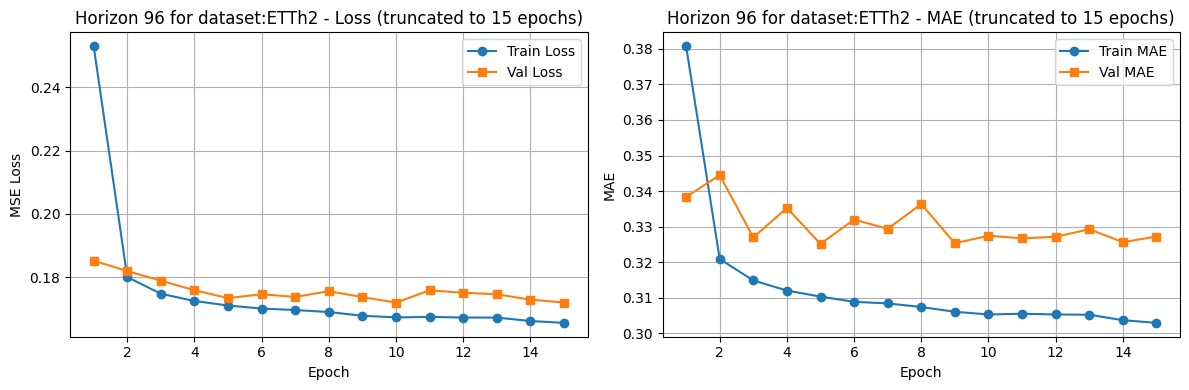

Saved training history plot to: results/ETTh2/loss_val/horizon_192_train_val_history_20260227_105154.png


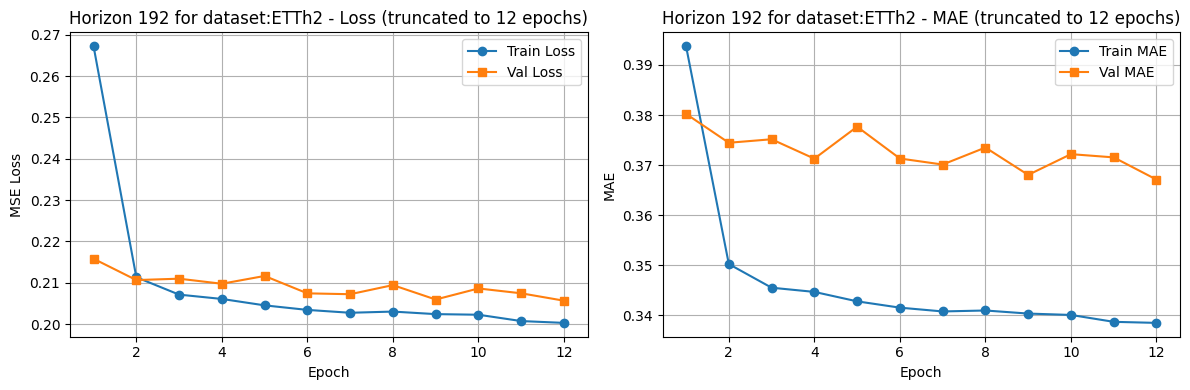

Saved training history plot to: results/ETTh2/loss_val/horizon_336_train_val_history_20260227_105154.png


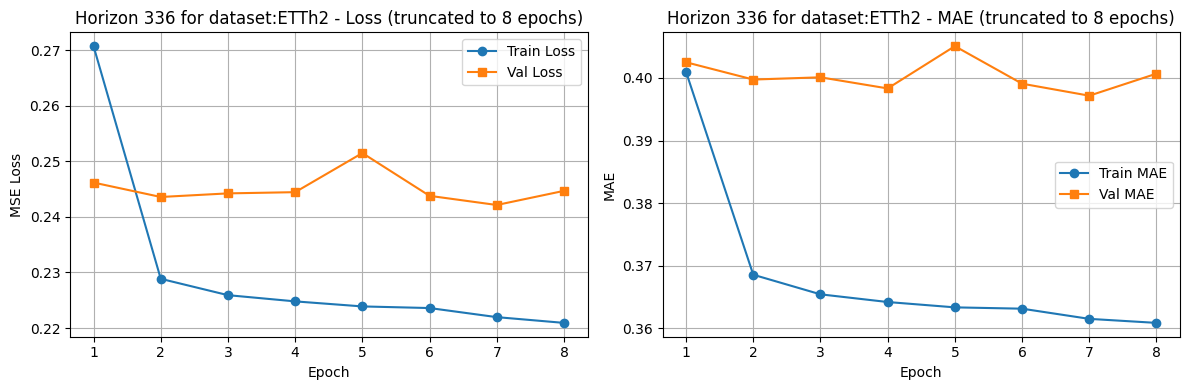

Saved training history plot to: results/ETTh2/loss_val/horizon_720_train_val_history_20260227_105154.png


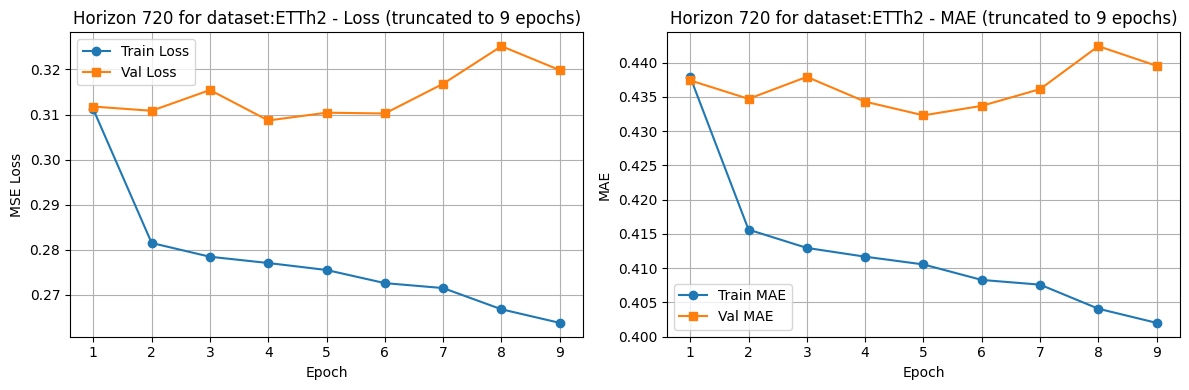

In [8]:
# ===============================
# Global cfg 
# ===============================
cfg = {
    96: {
        'input_len': input_len,
        'matrix_size':(21,16), ####### when feature is one , it converts to matrix
        'conv_size': 7,  ##### convolution kernel size
        'pred_len': 96,
        'num_features': num_features, # 1 for single target, 7 for multi target
        'n_layer_rubickattention': 4, # better:: even  number like 2,4,6,...32,64
        'n_heads_rubickattention': 512,
        'use_residual_rubickattention': False,
        'use_scaling_rubickattention': False,
        'dropout': 0.2,
        'dd_model': 512, # Dense Dimentional Model
        'use_rubickattention': True,
        "lr": 1e-4,
        "epochs": epochs,
        "batch_size": batch_size
    },
    192: {
        'input_len': input_len,
        'matrix_size':(21,16), ####### when feature is one , it converts to matrix
        'conv_size': 7,  ##### convolution kernel size
        'pred_len': 192,
        'num_features': num_features,  # 1 for single target, 7 for multi target 
        'n_layer_rubickattention': 2,  # even number like 2,4,6,8...32..64
        'n_heads_rubickattention': 256,
        'use_residual_rubickattention': False,
        'use_scaling_rubickattention': False,
        'dropout': 0.1,
        'dd_model': 326, # Dense Dimentional Model
        'use_rubickattention': True,
        "lr": 1e-4,
        "epochs": epochs,
        "batch_size": batch_size
    },
    336: {
        'input_len': input_len,
        'matrix_size':(21,16), ####### when feature is one , it converts to matrix
        'conv_size': 7,  ##### convolution kernel size
        'pred_len': 336,
        'num_features': num_features,  # 1 for single target, 7 for multi target
        'n_layer_rubickattention': 2,  # even number like 2,4,6,8...32..64
        'n_heads_rubickattention': 256,
        'use_residual_rubickattention': False,
        'use_scaling_rubickattention': False,
        'dropout': 0.1,
        'dd_model': 256, # Dense Dimentional Model
        'use_rubickattention': True,
        "lr": 1e-4,
        "epochs": epochs,
        "batch_size": batch_size
    },
    720: {
        'input_len': input_len,
        'matrix_size':(21,16), ####### when feature is one , it converts to matrix
        'conv_size': 7,  ##### convolution kernel size
        'pred_len': 720,
        'num_features': num_features, # 1 for single features
        'n_layer_rubickattention': 2, # even number like 2,4,6,8...32..64
        'n_heads_rubickattention': 128,
        'use_residual_rubickattention': False,
        'use_scaling_rubickattention': False,
        'dropout': 0.1,
        'dd_model': 128, # Dense Dimentional Model
        'use_rubickattention': True,
        "lr": 1e-4,
        "epochs": epochs,
        "batch_size": batch_size
    }
}

# ===============================
# Train & Evaluate Function (unchanged)
# ===============================
def train_and_evaluate(x_train, y_train, x_val, y_val, x_test, y_test, cfg):
    batch_train, seq_len, features = x_train.shape
    batch_val, seq_len, features = x_val.shape
    batch_test, seq_len, features = x_test.shape
    if features == 1:
             cfg['input_len'] = cfg['matrix_size'][0]
             cfg['num_features'] = cfg['matrix_size'][1]
             x_train = x_train.reshape(batch_train, cfg['input_len'] , cfg['num_features'])
             x_val = x_val.reshape(batch_val, cfg['input_len'] , cfg['num_features'])
             x_test = x_test.reshape(batch_test, cfg['input_len'] , cfg['num_features'])

    model = Rubick_Attention_Model(
        input_len=cfg['input_len'],
        pred_len=cfg['pred_len'],
        num_features=cfg['num_features'],
        n_layer_rubickattention=cfg['n_layer_rubickattention'],
        use_rubickattention=cfg['use_rubickattention'],
        n_heads_rubickattention=cfg['n_heads_rubickattention'],
        use_residual_rubickattention=cfg['use_residual_rubickattention'],
        use_scaling_rubickattention=cfg['use_scaling_rubickattention'],
        dropout=cfg['dropout'],
        dd_model=cfg['dd_model'],
        conv_size=cfg['conv_size']
    )
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(cfg["lr"]),
        loss="mse",
        metrics=["mae"]
    )
    
    print(f"Total parameters: {model.count_params():,}")
    print("DEBUG: Printing model summary...")

    history = model.fit(
        x_train, y_train,
        validation_data=(x_val, y_val),
        epochs=cfg["epochs"],
        batch_size=cfg["batch_size"],
        verbose=1,
        callbacks=[
            tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True, monitor='val_loss'),
            tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=3)
        ]
    )
    # Evaluate on test
    test_metrics = model.evaluate(x_test, y_test, verbose=0)
    # Explicitly delete model
    
    # Make sure test_metrics is a tuple: (MSE, MAE)
    if isinstance(test_metrics, (list, tuple)):
        mse, mae = test_metrics[0], test_metrics[1]
    else:
        # only loss is returned
        mse, mae = test_metrics, None
    print(f"DEBUG: Training completed for pred_len={cfg['pred_len']}")
    return history, (mse, mae)

# ===============================
# Run Experiments (tuned)
# ===============================
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

# Initialize the dictionary to store histories
train_val_histories = {}

results = []

for H, cfg in cfg.items():
    print(f"\n===== Horizon {H} =====")
    histories, mse_runs, mae_runs = [], [], []

    for run in range(RUNS):
        tf.keras.backend.clear_session()
        set_seed(42 + run)

        # Prepare data for this horizon
        x_train_scaled, y_train_scaled, x_val_scaled, y_val_scaled, x_test_scaled, y_test_scaled, scaler_X, scaler_Y, y_test_orig = input_pred_len(input_len, H)

        history, (mse, mae) = train_and_evaluate(
            x_train_scaled, y_train_scaled,
            x_val_scaled, y_val_scaled,
            x_test_scaled, y_test_scaled,
            cfg
        )

        mse_runs.append(mse)
        mae_runs.append(mae)
        histories.append(history)
        print(f"===== Horizon {H} ===== Run {run+1}: MSE={mse:.4f}, MAE={mae:.4f}")
    
    # save mean history per horizon
    train_val_histories[H] = histories
    results.append({
        'Horizon': H,
        'MSE_mean': np.mean(mse_runs),
        'MSE_std': np.std(mse_runs),
        'MAE_mean': np.mean(mae_runs),
        'MAE_std': np.std(mae_runs)
    })


# Display results
print("\n" + "="*50)
print("FINAL RESULTS:")
print("="*50)
for res in results:
    print(f"Horizon {res['Horizon']}:")
    print(f"  MSE: {res['MSE_mean']:.4f} ± {res['MSE_std']:.4f}")
    print(f"  MAE: {res['MAE_mean']:.4f} ± {res['MAE_std']:.4f}")
    print()

from datetime import datetime
import os

# Create result directory
RESULT_DIR = f"results/{dataset_name}/loss_val"
os.makedirs(RESULT_DIR, exist_ok=True)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Plot training histories
if train_val_histories:  # Only plot if there are histories
    for H, histories in train_val_histories.items():
        plt.figure(figsize=(12,4))
        
        # Find the minimum number of epochs across all runs for this horizon
        min_epochs = min([len(h.history['loss']) for h in histories])
        
        # Truncate all histories to the same length (minimum epochs)
        loss_train_list = [h.history['loss'][:min_epochs] for h in histories]
        loss_val_list = [h.history['val_loss'][:min_epochs] for h in histories]
        mae_train_list = [h.history['mae'][:min_epochs] for h in histories]
        mae_val_list = [h.history['val_mae'][:min_epochs] for h in histories]
        
        # Compute mean per epoch across runs
        loss_train = np.mean(loss_train_list, axis=0)
        loss_val = np.mean(loss_val_list, axis=0)
        mae_train = np.mean(mae_train_list, axis=0)
        mae_val = np.mean(mae_val_list, axis=0)
        epochs_arr = range(1, min_epochs + 1)

        # Loss
        plt.subplot(1,2,1)
        plt.plot(epochs_arr, loss_train, '-o', label='Train Loss')
        plt.plot(epochs_arr, loss_val, '-s', label='Val Loss')
        plt.xlabel("Epoch")
        plt.ylabel("MSE Loss")
        plt.title(f"Horizon {H} for dataset:{dataset_name} - Loss (truncated to {min_epochs} epochs)")
        plt.grid(True)
        plt.legend()

        # MAE
        plt.subplot(1,2,2)
        plt.plot(epochs_arr, mae_train, '-o', label='Train MAE')
        plt.plot(epochs_arr, mae_val, '-s', label='Val MAE')
        plt.xlabel("Epoch")
        plt.ylabel("MAE")
        plt.title(f"Horizon {H} for dataset:{dataset_name} - MAE (truncated to {min_epochs} epochs)")
        plt.grid(True)
        plt.legend()

        plt.tight_layout()
        
        # Save the figure BEFORE showing it
        history_plot_path = os.path.join(
            RESULT_DIR,
            f"horizon_{H}_train_val_history_{timestamp}.png"
        )
        plt.savefig(history_plot_path, dpi=300, bbox_inches="tight")
        print(f"Saved training history plot to: {history_plot_path}")
        
        plt.show()
        plt.close()  # Close the figure to free memory
        
else:
    print("No training histories to plot.")

## Evaluation

### References (Official Benchmarks for ETTh2)

[1] Yuqi Nie, et al.  
**A Time Series is Worth 64 Words: Long-Term Forecasting with Transformers (PatchTST)**  
*arXiv preprint, 2022*  
https://arxiv.org/abs/2211.14730

[2] Haixu Wu, et al.  
**Autoformer: Decomposition Transformers with Auto-Correlation for Long-Term Series Forecasting**  
*NeurIPS 2021*  
Supplementary results (ETTh1/ETTh2):  
https://ise.thss.tsinghua.edu.cn/~mlong/doc/Autoformer-supp-nips21.pdf

[3] Ailing Zeng, et al.  
**Are Transformers Effective for Time Series Forecasting? (DLinear / NLinear)**  
*AAAI Conference on Artificial Intelligence, 2023*  
https://ojs.aaai.org/index.php/AAAI/article/view/26317

[4] Yong Liu, et al.  
**TimesNet: Temporal Network for Multivariate Time Series Forecasting**  
*International Conference on Learning Representations (ICLR), 2024*  
https://proceedings.iclr.cc/paper_files/paper/2024/file/532aa4d1d650768de30e98f50ca86328-Paper-Conference.pdf

[5] ETDataset Authors  
**Electricity Transformer Temperature (ETT) Dataset Description**  
Official dataset source:  
https://github.com/zhouhaoyi/ETDataset

[6] TSLib Contributors  
**Time Series Library (Unified Benchmark for Long-Term Forecasting)**  
Used by PatchTST, Autoformer, FEDformer, TimesNet  
https://github.com/thuml/Time-Series-Library


### Evaluation





,Model,MSE96,MAE96,MSE192,MAE192,MSE336,MAE336,MSE720,MAE720
0,PatchTST,0.297000,0.349000,0.380000,0.400000,0.428000,0.432000,0.42800,0.4390
1,Autoformer,0.302000,0.348000,0.388000,0.400000,0.426000,0.433000,0.43100,0.4520
2,DLinear,0.346000,0.388000,0.456000,0.452000,0.482000,0.486000,0.51500,0.4860
3,TimesNet,0.305000,0.352000,0.424000,0.439000,0.456000,0.473000,0.47600,0.4730
4,RubickAttention,0.130854,0.280077,0.175803,0.331776,0.211155,0.369755,0.27245,0.4239


✅ Table saved to: results/ETTh2/test/ETTh2_SOTA_RubickAttention_Table_20260227_1051.docx


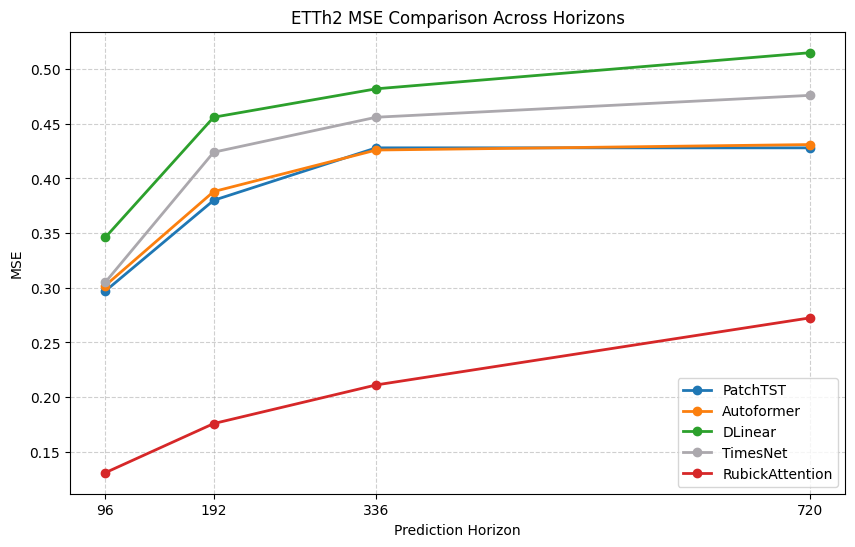

✅ MSE plot saved to: results/ETTh2/test/ETTh2_MSE_Comparison_20260227_1051.png


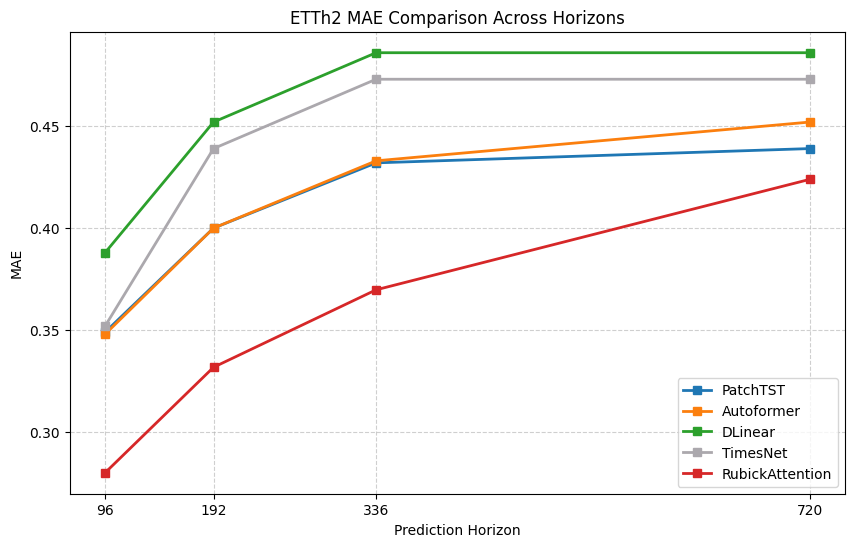

✅ MAE bar plot saved to: results/ETTh2/test/ETTh2_MAE_Comparison_bar_20260227_1051.png


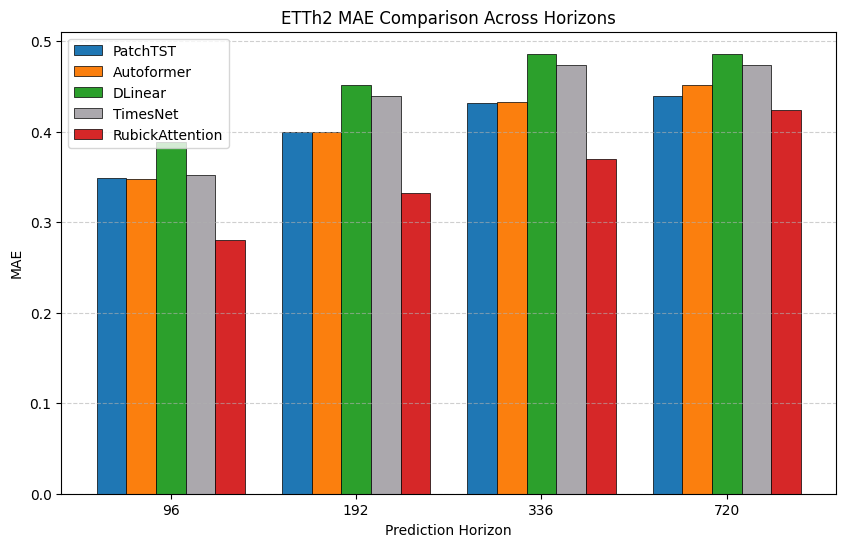

In [9]:
# ===============================
# OFFICIAL SOTA benchmark results on ETTh2 (test, normalized)
# Only models with official reported results
# ===============================
sota_results = {
    "Model": [
        "PatchTST",
        "Autoformer",
        "DLinear",
        "TimesNet",
        "RubickAttention"  # our model
    ],

    "Horizon_96": [
        {"MSE": 0.297, "MAE": 0.349},  # PatchTST
        {"MSE": 0.302, "MAE": 0.348},  # Autoformer
        {"MSE": 0.346, "MAE": 0.388},  # DLinear
        {"MSE": 0.305, "MAE": 0.352},  # TimesNet
        {"MSE": None,  "MAE": None}    # RubickAttention
    ],

    "Horizon_192": [
        {"MSE": 0.380, "MAE": 0.400},
        {"MSE": 0.388, "MAE": 0.400},
        {"MSE": 0.456, "MAE": 0.452},
        {"MSE": 0.424, "MAE": 0.439},
        {"MSE": None,  "MAE": None}
    ],

    "Horizon_336": [
        {"MSE": 0.428, "MAE": 0.432},
        {"MSE": 0.426, "MAE": 0.433},
        {"MSE": 0.482, "MAE": 0.486},
        {"MSE": 0.456, "MAE": 0.473},
        {"MSE": None,  "MAE": None}
    ],

    "Horizon_720": [
        {"MSE": 0.428, "MAE": 0.439},
        {"MSE": 0.431, "MAE": 0.452},
        {"MSE": 0.515, "MAE": 0.486},
        {"MSE": 0.476, "MAE": 0.473},
        {"MSE": None,  "MAE": None}
    ]
}

# ===============================
# Fill RubickAttention results
# ===============================
for res in results:  # your experimental results
    horizon = res['Horizon']
    mse = res['MSE_mean']
    mae = res['MAE_mean']

    col_name = f'Horizon_{horizon}'
    sota_results[col_name][-1] = {
        "MSE": mse,
        "MAE": mae  
    }

df_list = []
for i, model in enumerate(sota_results["Model"]):
    row = {"Model": model}
    for h in [96, 192, 336, 720]:
        metrics = sota_results[f"Horizon_{h}"][i]
        row[f"MSE{h}"] = metrics["MSE"]
        row[f"MAE{h}"] = metrics["MAE"]

    df_list.append(row)

df_results_full = pd.DataFrame(df_list)

display(df_results_full)

# ===============================
# save table in docx format
# ===============================
from datetime import datetime
RESULT_DIR = f"results/{dataset_name}/test"
os.makedirs(RESULT_DIR, exist_ok=True)

timestamp = datetime.now().strftime("%Y%m%d_%H%M")
from docx import Document

doc = Document()
doc.add_heading(f"SOTA + RubickAttention Results on {dataset_name}", level=1)

table = doc.add_table(rows=1, cols=len(df_results_full.columns))
table.style = 'Table Grid'

# Header
hdr_cells = table.rows[0].cells
for i, col in enumerate(df_results_full.columns):
    hdr_cells[i].text = col

# Data rows
for _, row in df_results_full.iterrows():
    row_cells = table.add_row().cells
    for i, value in enumerate(row):
        row_cells[i].text = f"{value:.4f}" if isinstance(value, float) else str(value)

doc_path = os.path.join(
    RESULT_DIR,
    f"{dataset_name}_SOTA_RubickAttention_Table_{timestamp}.docx"
)
doc.save(doc_path)
# ===============================
# color map per model
# ===============================
model_colors = {
    "PatchTST":    "#1f77b4",  # blue
    "Autoformer":  "#fb7f0e",  # orange
    "DLinear":     "#2ca02c",  # green
    "TimesNet":    "#aba8ad",  # purple
    "RubickAttention": "#d62728",  # red (highlight your model)
}

horizons = [96, 192, 336, 720]
plt.figure(figsize=(10, 6))

for _, row in df_results_full.iterrows():
    model = row["Model"]
    mse_vals = [row[f"MSE{h}"] for h in horizons]

    plt.plot(
        horizons,
        mse_vals,
        marker='o',
        linewidth=2,
        label=model,
        color=model_colors[model]
    )
plt.xticks(horizons)  # ensures only these horizon numbers appear on x-axis
plt.xlabel("Prediction Horizon")
plt.ylabel("MSE")
plt.title(f"{dataset_name} MSE Comparison Across Horizons")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
print(f"✅ Table saved to: {doc_path}")
mse_plot_path = os.path.join(
    RESULT_DIR,
    f"{dataset_name}_MSE_Comparison_{timestamp}.png"
)
plt.savefig(mse_plot_path, dpi=300, bbox_inches="tight")
plt.show()
plt.figure(figsize=(10, 6))

for _, row in df_results_full.iterrows():
    model = row["Model"]
    mae_vals = [row[f"MAE{h}"] for h in horizons]

    plt.plot(
        horizons,
        mae_vals,
        marker='s',
        linewidth=2,
        label=model,
        color=model_colors[model]
    )
plt.xticks(horizons)  # ensures only these horizon numbers appear on x-axis
plt.xlabel("Prediction Horizon")
plt.ylabel("MAE")
plt.title(f"{dataset_name} MAE Comparison Across Horizons")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
print(f"✅ MSE plot saved to: {mse_plot_path}")
mae_plot_path = os.path.join(
    RESULT_DIR,
    f"{dataset_name}_MAE_Comparison_{timestamp}.png"
)
plt.savefig(mae_plot_path, dpi=300, bbox_inches="tight")
plt.show()
if model == "RubickAttention":
    linewidth = 3.5
    marker = "D"
else:
    linewidth = 2
    marker = "o"


# --- Set up bar positions ---
num_models = len(df_results_full)
num_horizons = len(horizons)
x = np.arange(num_horizons)                     # the label locations
bar_width = 0.8 / num_models                    # width of each bar

# --- Create the plot ---
plt.figure(figsize=(10, 6))

for i, (_, row) in enumerate(df_results_full.iterrows()):
    model = row["Model"]
    mae_vals = [row[f"MAE{h}"] for h in horizons]
    
    # Offset bars for each model within a horizon group
    x_positions = x + i * bar_width - (num_models - 1) * bar_width / 2
    plt.bar(x_positions, mae_vals, width=bar_width, 
            label=model, color=model_colors[model], edgecolor='black', linewidth=0.5)

# --- Customize the plot ---
plt.xlabel("Prediction Horizon")
plt.ylabel("MAE")
plt.title(f"{dataset_name} MAE Comparison Across Horizons")
plt.xticks(x, horizons)                          # set horizon numbers as tick labels
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6, axis='y')

# --- Save and show ---
mae_plot_path = os.path.join(
    RESULT_DIR,
    f"{dataset_name}_MAE_Comparison_bar_{timestamp}.png"
)
plt.savefig(mae_plot_path, dpi=300, bbox_inches="tight")
print(f"✅ MAE bar plot saved to: {mae_plot_path}")
plt.show()